# Seismogram Objects
## *Gary L. Pavlis*

## Overview
This is a notebook students in the MsPASS class will want to read and run outside the scheduled class period.   It contains some foundational material on what we call a `Seismogram` object, which encapsulates the concept of the output records of a three-component sensor.  Some key points this tutorial illustrates are:
*  The data array of a `Seismogram` is a 3Xn_samples matrix
*  The object has methods to handle coordinate transformations automatically.   I emphasize they are "methods"  not functions applied to data to transform the data matrix.
*  The object has failsafes you can use to make sure the data are oriented the way you expect them to be.   

## Initializations
First, the stock incantation that most MsPASS workflows should use for initialization.   

In [1]:
from mspasspy.db.database import Database
import mspasspy.client as msc
mspass_client = msc.Client()
dask_client = mspass_client.get_scheduler()
db = mspass_client.get_database("ES2026")

## Reading and plotting Seismogram objects
First, read a single `Seismogram` object we can experiment with.   I'm going to use nontrivial query to select a single Seismogram I know from experimentation has a visible signal without any filtering.   

In [2]:
from mspasspy.algorithms.basic import ator
from mspasspy.graphics import SeismicPlotter
from mspasspy.algorithms.signals import detrend
# query is necessary because not all Seismogram data have Ptime set.  This guarantees we find the first one that does have it set
doc = db.wf_Seismogram.find_one({'arrival_time' : {'$exists' : 1}})
d = db.read_data(doc,collection='wf_Seismogram')
# shift data so 0 is approximate P wave arrival time
Ptime = d['arrival_time']
d = ator(d,Ptime)
d=detrend(d)


Because a `Seismogram` is a native MsPASS data object the easiest way to plot one is to use the MsPASS plotter.  This box does that to plot the single Seismogram we just loaded.

In [3]:
from mspasspy.graphics import SeismicPlotter
import matplotlib.pyplot as plt
# instantiate the plotter
plotter = SeismicPlotter(normalize=True)
# The default "style" is not the best for Seismograms - change to wiggle trace variable area (wtva)
plotter.change_style('wtva')

Now plot these data.  We also, however, want to shift the time reference so the P wave arrival time defines time 0.   The `ator` function does here:

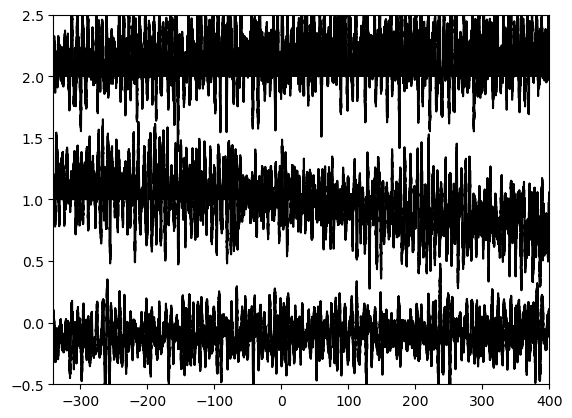

In [4]:
Ptime = d["arrival_time"]   # extracts the ANF pick for the P wave first arrival
d = ator(d,Ptime)    # does the time shift
plotter.plot(d)
plt.show()   # plotter uses matplotlib and like all matplotlib graphics a figure should be terminated with this incantation


Noting the components are plotted from the top down are BHE, BHN, and BHZ.   

Note, if you prefer matplotlib graphics you can use them but the syntax it takes a lot more code and some ugly numpy style array gyrations.  For your education, here is the same data plotted with matplotlib subplots.

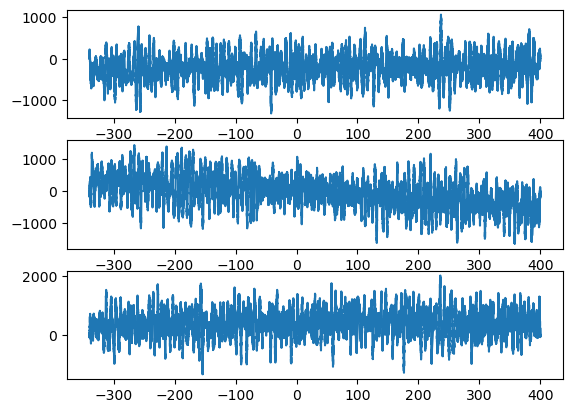

In [5]:
fig,ax = plt.subplots(3)
for i in range(3):
    ax[i].plot(d.time_axis(),d.data[i,:])
plt.show()

## Seismogram concepts
The issue we need to address at this point is a unique feature of MsPASS compared to any other framework we know.  The `Seismogram` class was designed to enscapsulate key concepts that define what a three component seismogram is.   There are several features of `Seismogram` that are relevant to this tutorial:
1.  A `Seismogram` object keeps track of the orientation of the components in space relative to the local geographic reference frame at the station.  We discussed this earlier, but we will dig into this a bit deeper here.
2.  A `Seismogram` unifies the generic concept of coordinate transformations to allow simple rotations to coordinates like RTZ to a general coordinate transformation using the `transform` method of `Seismogram` or the [transform function wrapper](http://www.mspass.org/python_api/mspasspy.algorithms.html#mspasspy.algorithms.basic.transform) wrapper function used for parallel processing constructs like those we will use below.  In this tutorial we will be using a particularly useful, but relatively complicated function useful for P wave receiver function processing, called [free_surface_transformation](http://www.mspass.org/python_api/mspasspy.algorithms.html#mspasspy.algorithms.basic.free_surface_transformation).
3.  Unless you apply a singular transformation, the data can always be restored to the standard coordinate reference frame of x1=EW, x2=NS, and x3=Z with the `rotate_to_standard` method of the data object or the [rotate_to_standard wrapper function](http://www.mspass.org/python_api/mspasspy.algorithms.html#mspasspy.algorithms.basic.rotate_to_standard).

To make this clearer we will explore that a bit before proceeding.  A more in depth version of this material can be found [here](https://github.com/mspass-team/mspass_tutorial/blob/master/notebooks/Three-ComponentBasics.ipynb).

First note the output of this simple code blocK:

In [6]:
print(d.cardinal())
print(d.tmatrix)

False
[[ 0.00000000e+00  0.00000000e+00  1.00000000e+00]
 [-5.23596383e-03  9.99986292e-01  2.64845403e-14]
 [ 9.99986292e-01  5.23596383e-03  2.64845403e-14]]


Note:
- The `cardinal` method returning False tells you the data are not in standard geographic coordinates (ENZ)
- The output of the `tmatrix` method shows that indeed the transformation is anything but an identity matrix because the order the coordinate is not standard.

WE fix that problem by applying the `rotate_to_standard` function:

In [7]:
from mspasspy.algorithms.basic import rotate_to_standard
d = rotate_to_standard(d)
print(d.cardinal())
print(d.tmatrix)

True
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


Note the transformation matrix is now an identity matrix - the definition of "cardinal" in MsPASS.  Hence, the `cardinal` method now returns True.

MsPASS has a relatively complete set of coordinate transformation operators from simple rotation around Z to the most sophisticated coordinate transformation for P wave data  commonly called the "free surface transformation". The theory for the matrix transformation is in Brian Kennett's (1983) book on layered media theory. We will apply that operator to these data as it is arguably the best way to prepare teleseismic P wave data for receiver function deconvolution.   A more complete tutorial on the transformation operators available for `Seismogram` objects can be found [here](https://github.com/mspass-team/mspass_tutorial/blob/master/notebooks/Three-ComponentBasics.ipynb).

The next code box defines a function that we can apply to `Seismogram` objects to apply the free surface transformation.  Note the operator requires us to know the ray parameter for the P wave being analyzed.  We set those values as Metadata attributes when we created this assembled data set with the notebook you ran prior to the start of the class.

In [8]:
import math
from mspasspy.ccore.seismic import SlownessVector
from mspasspy.algorithms.basic import free_surface_transformation
from mspasspy.ccore.utility import ErrorSeverity

def apply_FST(d,rayp_key="rayp_P",seaz_key='seaz',vp0=6.0,vs0=3.5):
    """
    Apply free surface transformation operator of Kennett (1983) to an input `Seismogram` 
    object.   Assumes ray parameter and azimuth data are stored as Metadata in the 
    input datum.  If the ray parameter or azimuth key are not defined an error 
    message will be posted and the datum will be killed before returning.  
    :param d:  datum to process
    :type d:  Seismogram
    :param rayp_key:   key to use to extract ray parameter to use to compute the 
    free surface transformation operator.  Note function assumes the ray parameter is
    spherical coordinate form:  R sin(theta)/V.   Default is "rayp_P".
    :param seaz_key:   key to use to extract station to event azimuth. Default is "seaz".
    :param vp0:  surface P wave velocity (km/s) to use for free surface transformation 
    :param vs0:  surface S wave velocity (km/s) to use for free surface transformation.
    """
    if d.is_defined(rayp_key) and d.is_defined(seaz_key):
        rayp = d[rayp_key]
        seaz = d[seaz_key]
        # Some basic seismology here.  rayp is the spherical earth ray parameter
        # R sin(theta)/v.  Free surface transformation needs apparent velocity 
        # at Earth's surface which is sin(theta)/v when R=Re.   Hence the following
        # simple convertion to get apparent slowness at surface  sin(theta)/v
        Re=6378.1
        umag = rayp/Re   # magnitude of slowness vector
        # seaz is back azimuth - slowness vector points in direction of propagation
        # with is 180 degrees away from back azimuth
        az = seaz + 180.0
        # component slowness vector components in local coordinates
        ux = umag * math.sin(az)
        uy = umag * math.cos(az)
        # FST implementation requires this special class called a Slowness Vector
        u = SlownessVector(ux,uy)
        d = free_surface_transformation(d,uvec=u,vp0=vp0,vs0=vs0)
    else:
        d.kill()
        message = "one of required attributes rayp_P or seaz were not defined for this datum"
        d.elog.log_error("apply_FST",message,ErrorSeverity.Invalid)
        
    return d

If you look at that function I just pasted in from elsewhere not it is going to ask for two Metadata values referenced with "rayp_key" and "seaz_key".  The docstring explains what they need to be.   Problem the following shows is neither is currently defined for the test datum we are playing with.

In [9]:
for k in ["rayp_","seaz"]:
    if k in d:
        print("datum has key=",k)
    else:
        print(f"Key={k} is not defined in this datum")

Key=rayp_ is not defined in this datum
Key=seaz is not defined in this datum


To fix that we need to paste in here another function we defined in the Session2 notebook.

In [10]:
import math
from mspasspy.ccore.seismic import SlownessVector
from mspasspy.ccore.utility import ErrorSeverity
from obspy.taup import TauPyModel
from obspy.geodetics.base import gps2dist_azimuth,kilometers2degrees

def set_PStime(d,
               Ptimekey="Ptime",
               Stimekey="Stime",
               model=None,
               receiver_collection="site",
              ):
    """
    Function to calculate P and S wave arrival time and set times 
    as the header (Metadata) fields defined by Ptimekey and Stimekey.
    Tries to handle some complexities of the travel time calculator 
    returns when one or both P and S aren't calculatable.  That is 
    the norm in or at the edge of the core shadow.  
    Requires source and receiver coordinates stored in the Metadata 
    of d.  Required source data is frozen as "source_lat", 
    "source_lon", "source_depth", and "source_time".   Receiver 
    data is similar but depends upon the value of `receiver_collection`.
    (see below).  If any of that required metadata is missing the 
    return will be killed with a message posted to elog.  
    
    :param d:  input TimeSeries datum.  Assumes datum's Metadata 
      contains stock source and channel attributes.  
    :param Ptimekey:  key used to define the header attribute that 
      will contain the computed P time.  Default "Ptime".
    :param model:  instance of obspy TauPyModel travel time engine. 
      Default is None.   That mode is slow as an new engine will be
      constructed on each call to the function.  Normal use should 
      pass an instance for greater efficiency.  
    :param receiver_collection:   normalizing collection used to 
      load receiver metadata.   In MsPASS normalizing attributes 
      are (by default) loaded with a prefix defining the collection 
      the came from.   The default for this argument is "site" which 
      means the function will attempt to fetch receiver location 
      data with the keys "site_lat" and "site_lon"  
    """
    if d.live:
        if model is None:
            model = TauPyModel(model="iasp91") 
        rlatkey=f"{receiver_collection}_lat"
        rlonkey=f"{receiver_collection}_lon"
        required_keys=["source_lat","source_lon","source_depth","source_time"]
        required_keys.append(rlatkey)
        required_keys.append(rlonkey)
        message = ""
        for key in required_keys:
            if key not in required_keys:
                message += "Missing required key={}\n".format(key)
        if len(message) > 0:
            d.kill()
            d.elog.log_error("setPStime",message,ErrorSeverity.Invalid)
        # extract required source attributes
        srclat=d["source_lat"]
        srclon=d["source_lon"]
        srcz=d["source_depth"]
        srct=d["source_time"] 
        # extract required channel attributes
        stalat=d[rlatkey]
        stalon=d[rlonkey]
        # set up and run travel time calculator
        georesult=gps2dist_azimuth(srclat,srclon,stalat,stalon)
        # obspy's function we just called returns distance in m in element 0 of a tuple
        # their travel time calculator it is degrees so we need this conversion
        dist=kilometers2degrees(georesult[0]/1000.0)
        arrivals=model.get_travel_times(source_depth_in_km=srcz,
                                            distance_in_degree=dist,
                                            phase_list=['P','S'])
        # always post this for as it is not cheap to compute
        # WARNING:  don't use common abbrevation delta - collides with data dt
        d['epicentral_distance']=dist
        # these are CSS3.0 shorthands s - station e - event
        esaz = georesult[1]
        seaz = georesult[2]
        # css3.0 names esax = event to source azimuth; seaz = source to event azimuth
        d['esaz']=esaz
        d['seaz']=seaz
        # get_travel_times returns an empty list if a P time cannot be 
        # calculated.  We trap that condition and kill the output 
        # with an error message
        if len(arrivals)==2:
            Ptime=srct+arrivals[0].time
            rayp = arrivals[0].ray_param
            Stime=srct+arrivals[1].time
            rayp_S = arrivals[1].ray_param
            d.put(Ptimekey,Ptime)
            d.put(Stimekey,Stime)
            # These keys are not passed as arguments but could be - a choice
            # Ray parameter is needed for free surface transformation operator
            # note tau p calculator in obspy returns p=R sin(theta)/V_0
            d.put("rayp_P",rayp)
            d.put("rayp_S",rayp_S)
        elif len(arrivals)==1:
            if arrivals[0].name == 'P':
                Ptime=srct+arrivals[0].time
                rayp = arrivals[0].ray_param
                d.put(Ptimekey,Ptime)
                d.put("rayp_P",rayp)
            else:
                # Not sure we can assume name is S
                if arrivals[0].name == 'S':
                    Stime=srct+arrivals[0].time
                    rayp_S = arrivals[0].ray_param
                    d.put(Stimekey,Stime)
                    d.put("rayp_S",rayp_S)
                else:
                    message = "Unexpected single phase name returned by taup calculator\n"
                    message += "Expected phase name S but got " + arrivals[0].name
                    d.elog.log_error("set_PStime",
                                     message,
                                     ErrorSeverity.Invalid)
                    d.kill()
                
    # Note python indents mean if an ensemble is marked dead this function just silenetly returns 
    # what it received doing nothing - correct mspass model
    return d

Run this on d to verify it works and to see the effect.

In [11]:
from mspasspy.db.normalize import ObjectIdMatcher,normalize
site_matcher = ObjectIdMatcher(db,
    collection="site",
    attributes_to_load=["_id","lat","lon","elev"],
                              )
source_matcher = ObjectIdMatcher(db,
    collection="source",
    attributes_to_load=["lat","lon","depth","time","_id","magnitude"],
  )
d = normalize(d,site_matcher)
print(d.live)
d = normalize(d,source_matcher)
print(d.live)

True
True


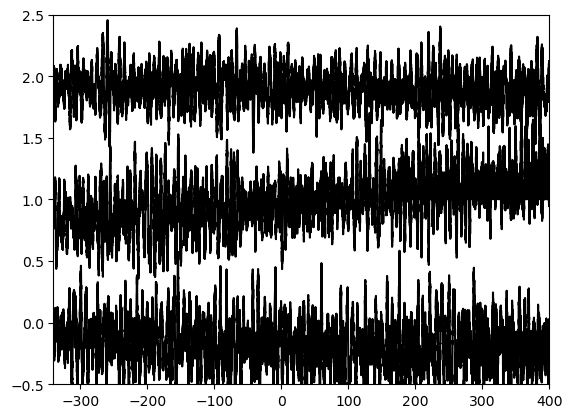

In [12]:
d = set_PStime(d)
d2=apply_FST(d)
plotter.plot(d2)
plt.show()
# plot is from bottom up SH, SV, P

Finally, that event is small enough that the P wave signal is overwhelmed by microseism noise.   We'll filter the data to something close to a traditional short period filter and plot the filtered original data and that after the free surface transformation operator was applied.

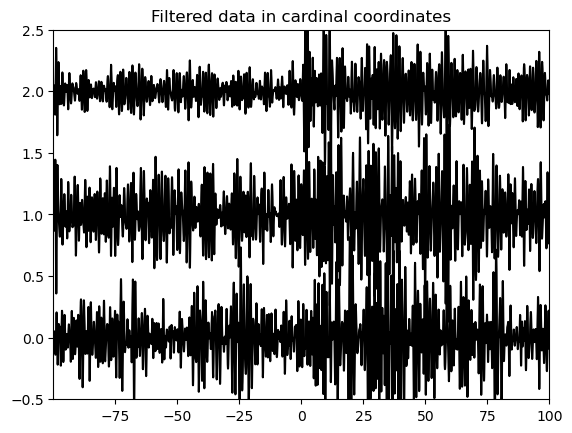

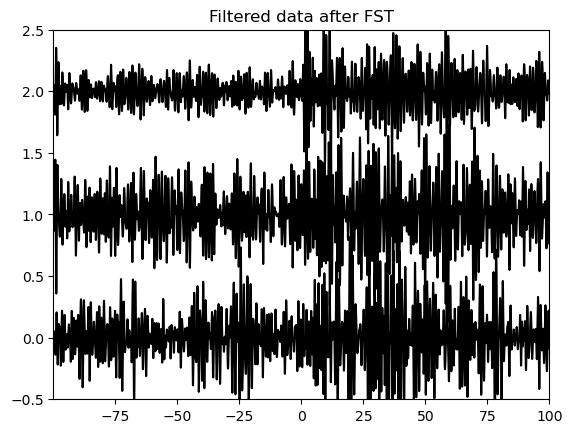

In [13]:
from mspasspy.algorithms.signals import filter
from mspasspy.algorithms.window import WindowData
d = WindowData(d,-100.0,100.0)
d2 = WindowData(d2,-100.0,100.0)
d = filter(d,type="bandpass",freqmin=0.75,freqmax=1.5)
d2 = filter(d2,type="bandpass",freqmin=0.75,freqmax=1.5)
plotter.title="Filtered data in cardinal coordinates"
plotter.plot(d)
plt.show()
plotter.title="Filtered data after FST"
plotter.plot(d2)
plt.show()

Not a very impressive signal, but it is educational on some basic observational seismology.   
1.  The magnitude frequency distribution means there far far more small earthquakes than large earthquakes.
2.  To reach teleseismic distances and produce P waves that travel through the upper mantle and still be detectable requires a minimum size earthquake around magnitude 4.5.  Note the only exception is regional phases like Pn and Lg that are a different thing.
3.  This event is clearly small (see exactly how small below).  Globally events smaller than about 5-6 are only visible at all in the traditional short period band depending on distance.  
4.  P waves from small events often have a visible signal only on the vertical/longitudinal components like this one.
5.  An analyst at ANF was able to pick this signal only because he/she could see the Z component in the context of other TA records - the advantage of array redundancy.   

In [14]:
# here is how small this event actually is
print("Magnitude of this event=",d["source_magnitude"])
print("Epicentral distance=",d['epicentral_distance'])

Magnitude of this event= 5.7
Epicentral distance= 94.86827265616533
